In [35]:
# import libraries
import numpy as np

# convolution
from scipy.signal import convolve2d

# to read an image from a url
from imageio.v2 import imread

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Manual 2D convolution in numpy/scipy

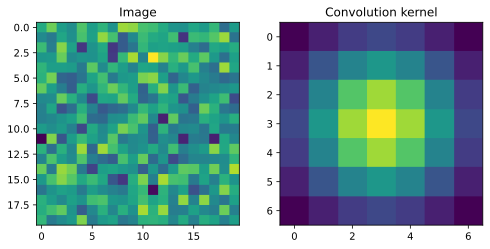

In [36]:
# image
imgN = 20
image = np.random.randn(imgN,imgN)

# convolution kernel
kernelN = 7
Y,X = np.meshgrid(np.linspace(-3,3,kernelN),np.linspace(-3,3,kernelN))
kernel = np.exp( -(X**2+Y**2)/7 )


# let's see what they look like
fig,ax = plt.subplots(1,2,figsize=(8,6))
ax[0].imshow(image)
ax[0].set_title('Image')

ax[1].imshow(kernel)
ax[1].set_title('Convolution kernel')

plt.show()

In [37]:
# now for the convolution
convoutput = np.zeros((imgN,imgN))
halfKr = kernelN//2

for rowi in range(halfKr,imgN-halfKr):
  for coli in range(halfKr,imgN-halfKr):

    # cut out a piece of the image
    pieceOfImg = image[rowi-halfKr:rowi+halfKr+1,coli-halfKr:coli+halfKr+1]     

    # dot product: element-wise multiply and sum (and flip the kernel for "real convolution")
    dotprod = np.sum( pieceOfImg*kernel[::-1,::-1] )

    # store the result for this pixel
    convoutput[rowi,coli] = dotprod

In [38]:
convoutput.shape

(20, 20)

In [39]:
# using scipy
convoutput2 = convolve2d(image,kernel,mode='valid')
convoutput2.shape

(14, 14)

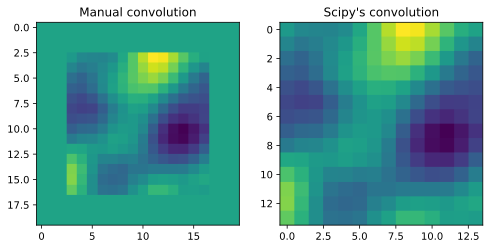

In [40]:
fig,ax = plt.subplots(1, 2, figsize=(8, 6))

ax[0].imshow(convoutput)
ax[0].set_title('Manual convolution')

ax[1].imshow(convoutput2)
ax[1].set_title("Scipy's convolution")

plt.show()

In [41]:
convoutput[halfKr:imgN-halfKr,halfKr:imgN-halfKr].shape

(14, 14)

Text(0.5, 1.0, "Scipy's convolution")

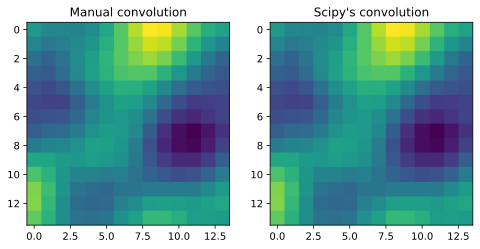

In [42]:
fig,ax = plt.subplots(1, 2, figsize=(8, 6))

ax[0].imshow(convoutput[halfKr:imgN-halfKr,halfKr:imgN-halfKr])
ax[0].set_title('Manual convolution')

ax[1].imshow(convoutput2)
ax[1].set_title("Scipy's convolution")

In [43]:
convoutput2 = convolve2d(image,kernel,mode='same')
convoutput2.shape

(20, 20)

Text(0.5, 1.0, "Scipy's convolution")

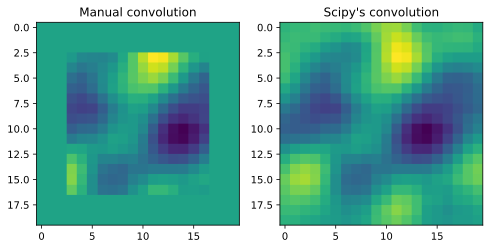

In [44]:
fig,ax = plt.subplots(1, 2, figsize=(8, 6))

ax[0].imshow(convoutput)
ax[0].set_title('Manual convolution')

ax[1].imshow(convoutput2)
ax[1].set_title("Scipy's convolution")

In [ ]:
import numpy as np

def conv2d_manual(image: np.ndarray, kernel: np.ndarray, mode: str = "same") -> np.ndarray:
    """
    Manual 2D convolution (like scipy.signal.convolve2d) for square/rectangular 2D arrays.

    Parameters
    ----------
    image : (H, W) array
    kernel : (Kh, Kw) array
    mode : "same" or "valid"
        - "valid": only positions where kernel fully overlaps image
        - "same" : output same HxW as image using zero-padding

    Returns
    -------
    out : array
        Convolution result.
    """
    if image.ndim != 2 or kernel.ndim != 2:
        raise ValueError("image and kernel must be 2D arrays")
    if mode not in {"same", "valid"}:
        raise ValueError("mode must be 'same' or 'valid'")

    H, W = image.shape
    Kh, Kw = kernel.shape

    # flip kernel for true convolution
    k = kernel[::-1, ::-1]

    if mode == "valid":
        out_h = H - Kh + 1
        out_w = W - Kw + 1
        if out_h <= 0 or out_w <= 0:
            raise ValueError("kernel must be smaller than or equal to image in 'valid' mode")

        out = np.zeros((out_h, out_w), dtype=np.result_type(image, kernel))
        for r in range(out_h):
            for c in range(out_w):
                patch = image[r:r + Kh, c:c + Kw]
                out[r, c] = np.sum(patch * k)
        return out

    # mode == "same": zero-pad so output is HxW
    pad_top = Kh // 2
    pad_bottom = Kh - 1 - pad_top
    pad_left = Kw // 2
    pad_right = Kw - 1 - pad_left

    imgp = np.pad(
        image,
        ((pad_top, pad_bottom), (pad_left, pad_right)),
        mode="constant",
        constant_values=0,
    )

    out = np.zeros((H, W), dtype=np.result_type(image, kernel))
    for r in range(H):
        for c in range(W):
            patch = imgp[r:r + Kh, c:c + Kw]
            out[r, c] = np.sum(patch * k)
    return out

convoutput.shape=(14, 14)
convoutput2.shape=(14, 14)


Text(0.5, 1.0, "Scipy's convolution")

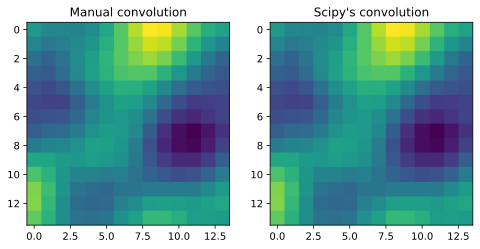

In [46]:
fig,ax = plt.subplots(1, 2, figsize=(8, 6))
convoutput = conv2d_manual(image,kernel,mode='valid')
print(f'{convoutput.shape=}')
ax[0].imshow(convoutput)
ax[0].set_title('Manual convolution')
convoutput2 = convolve2d(image,kernel,mode='valid')
ax[1].imshow(convoutput2)
print(f'{convoutput2.shape=}')
ax[1].set_title("Scipy's convolution")

convoutput.shape=(20, 20)
convoutput2.shape=(20, 20)


Text(0.5, 1.0, "Scipy's convolution")

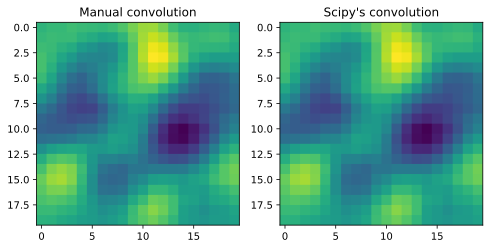

In [47]:
fig,ax = plt.subplots(1, 2, figsize=(8, 6))
convoutput = conv2d_manual(image,kernel,mode='same')
print(f'{convoutput.shape=}')
ax[0].imshow(convoutput)
ax[0].set_title('Manual convolution')
convoutput2 = convolve2d(image,kernel,mode='same')
print(f'{convoutput2.shape=}')
ax[1].imshow(convoutput2)
ax[1].set_title("Scipy's convolution")

In [ ]:
# now for the convolution
def manual_conv2d(image, kernel, mode):
  kernelN = kernel.shape[0]
  halfKr = kernelN//2
  imgN = image.shape[0]
  
  # below is same as implementation in video
  # if mode == 'valid':
  #   convoutput = np.zeros((imgN,imgN))
  #   for rowi in range(halfKr,imgN-halfKr):
  #     for coli in range(halfKr,imgN-halfKr):
  #       pieceOfImg = image[rowi-halfKr:rowi+halfKr+1,coli-halfKr:coli+halfKr+1]     
  #       dotprod = np.sum( pieceOfImg*kernel[::-1,::-1] )
  #       convoutput[rowi,coli] = dotprod
  #   return convoutput[halfKr:imgN-halfKr, halfKr:imgN-halfKr]

  # this is a cleaner implementation
  if mode == 'valid':
    convoutput = np.zeros((imgN-kernelN+1,imgN-kernelN+1))
    for rowi in range(convoutput.shape[0]):
      for coli in range(convoutput.shape[1]):
        pieceOfImg = image[rowi:rowi + kernelN, coli:coli+kernelN]     
        dotprod = np.sum( pieceOfImg*kernel[::-1,::-1] )
        convoutput[rowi,coli] = dotprod
    return convoutput
  elif mode == 'same':
    convoutput = np.zeros((imgN,imgN))
    image = np.pad(image, pad_width=halfKr, mode='constant', constant_values=0)
    for rowi in range(imgN):
      for coli in range(imgN):
        pieceOfImg = image[rowi:rowi+kernelN,coli:coli+kernelN]     
        dotprod = np.sum( pieceOfImg*kernel[::-1,::-1] )
        convoutput[rowi,coli] = dotprod
    return convoutput
  else:
    raise f'{mode=} unimplemented'

convoutput.shape=(14, 14)
convoutput2.shape=(14, 14)


Text(0.5, 1.0, "Scipy's convolution")

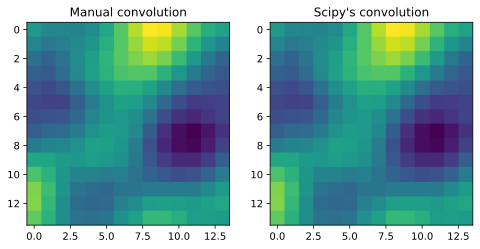

In [75]:
fig,ax = plt.subplots(1, 2, figsize=(8, 6))
convoutput = manual_conv2d(image,kernel,mode='valid')
print(f'{convoutput.shape=}')
ax[0].imshow(convoutput)
ax[0].set_title('Manual convolution')
convoutput2 = convolve2d(image,kernel,mode='valid')
print(f'{convoutput2.shape=}')
ax[1].imshow(convoutput2)
ax[1].set_title("Scipy's convolution")

convoutput.shape=(20, 20)
convoutput2.shape=(20, 20)


Text(0.5, 1.0, "Scipy's convolution")

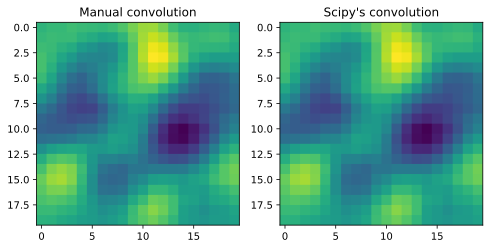

In [76]:
fig,ax = plt.subplots(1, 2, figsize=(8, 6))
convoutput = manual_conv2d(image,kernel,mode='same')
print(f'{convoutput.shape=}')
ax[0].imshow(convoutput)
ax[0].set_title('Manual convolution')
convoutput2 = convolve2d(image,kernel,mode='same')
print(f'{convoutput2.shape=}')
ax[1].imshow(convoutput2)
ax[1].set_title("Scipy's convolution")

# Examples of convolution with different kernels in a real image

(1675, 3000, 3)
(1675, 3000)


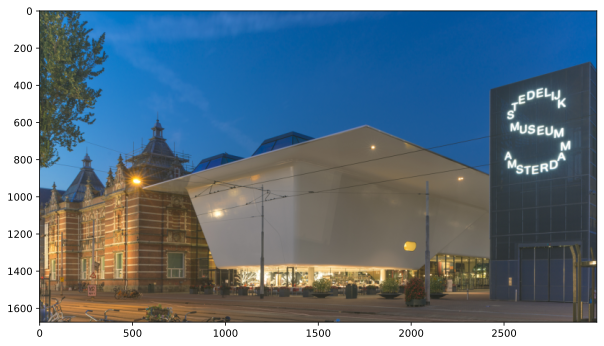

In [ ]:
# read a pic from the web (Wikimedia requires a User-Agent header)
from io import BytesIO
from urllib.request import Request, urlopen

url = 'https://upload.wikimedia.org/wikipedia/commons/6/61/De_nieuwe_vleugel_van_het_Stedelijk_Museum_Amsterdam.jpg'
req = Request(url, headers={'User-Agent': 'Mozilla/5.0 (compatible; ImageLoader/1.0)'})
with urlopen(req) as resp:
    bathtub = imread(BytesIO(resp.read()))

# check the size
print(bathtub.shape)

# let's see what the famous Bathtub Museum looks like
fig = plt.figure(figsize=(10,6))
plt.imshow(bathtub);

# transform image to 2D for convenience (not necessary for convolution!)
bathtub = np.mean(bathtub,axis=2)
bathtub = bathtub/np.max(bathtub)

# check the size again
print(bathtub.shape)

In [ ]:
# hand-craft two convolution kernels

# vertical kernel
VK = np.array([ [1,0,-1],
                [1,0,-1],
                [1,0,-1] ])

# horizontal kernel
HK = np.array([ [ 1, 1, 1],
                [ 0, 0, 0],
                [-1,-1,-1] ])

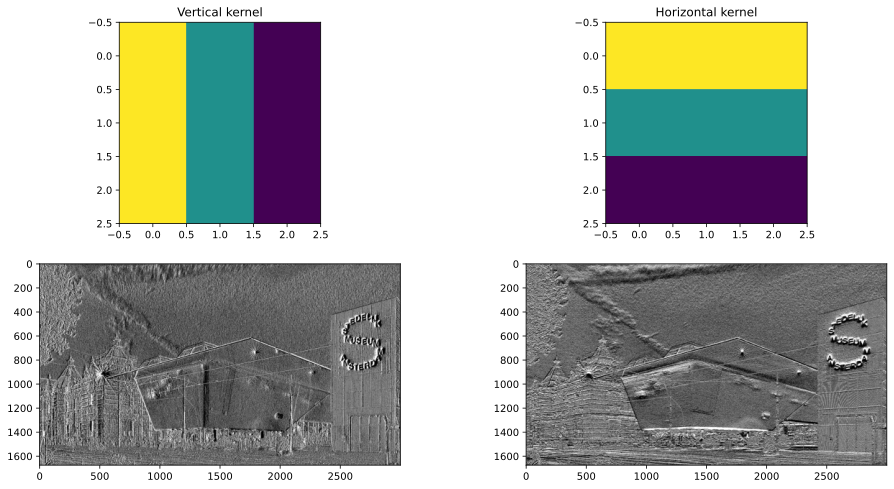

In [ ]:
fig,ax = plt.subplots(2,2,figsize=(16,8))

ax[0,0].imshow(VK)
ax[0,0].set_title('Vertical kernel')

ax[0,1].imshow(HK)
ax[0,1].set_title('Horizontal kernel')


# run convolution and show the result
convres_v = convolve2d(bathtub,VK,mode='same')
ax[1,0].imshow(convres_v,cmap='gray',vmin=0,vmax=.01)

convres_h = convolve2d(bathtub,HK,mode='same')
ax[1,1].imshow(convres_h,cmap='gray',vmin=0,vmax=.01)

plt.show()

In [ ]:
print(convres_v.shape)
print(convres_h.shape)

(1675, 3000)
(1675, 3000)


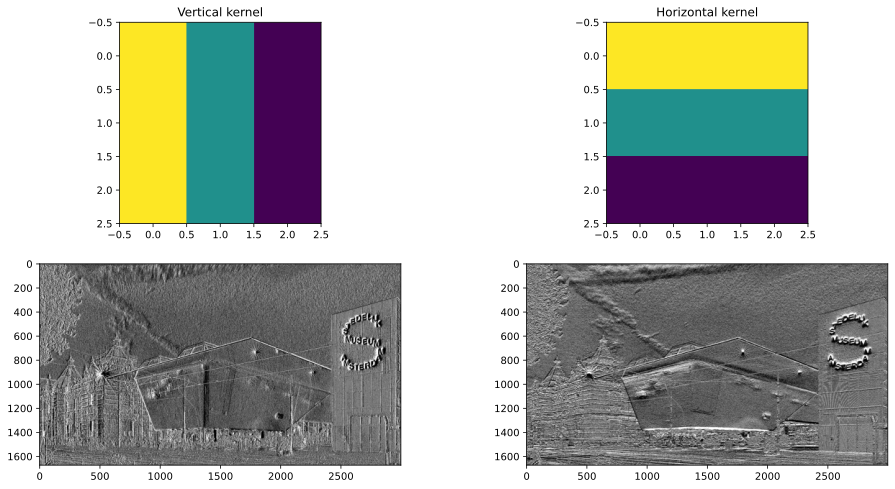

In [ ]:
fig,ax = plt.subplots(2,2,figsize=(16,8))

ax[0,0].imshow(VK)
ax[0,0].set_title('Vertical kernel')

ax[0,1].imshow(HK)
ax[0,1].set_title('Horizontal kernel')


# run convolution and show the result
convres_v = convolve2d(bathtub,VK,mode='valid')
ax[1,0].imshow(convres_v,cmap='gray',vmin=0,vmax=.01)

convres_h = convolve2d(bathtub,HK,mode='valid')
ax[1,1].imshow(convres_h,cmap='gray',vmin=0,vmax=.01)

plt.show()

In [ ]:
print(convres_v.shape)
print(convres_h.shape)

(1673, 2998)
(1673, 2998)


# Now in PyTorch

In [ ]:
# first, translate everything into a tensor
import torch
import torch.nn.functional as F

VK_t = torch.as_tensor(VK, dtype=torch.float64).view(1, 1, 3, 3)
HK_t = torch.as_tensor(HK, dtype=torch.float64).view(1, 1, 3, 3)
bathtub_t = torch.as_tensor(bathtub, dtype=torch.float64).view(1, 1, bathtub.shape[0], bathtub.shape[1])

print(VK_t.shape)
print(bathtub_t.shape)

torch.Size([1, 1, 3, 3])
torch.Size([1, 1, 1675, 3000])


In [ ]:
C = F.conv2d(bathtub_t,VK_t)
print(C.shape)

torch.Size([1, 1, 1673, 2998])


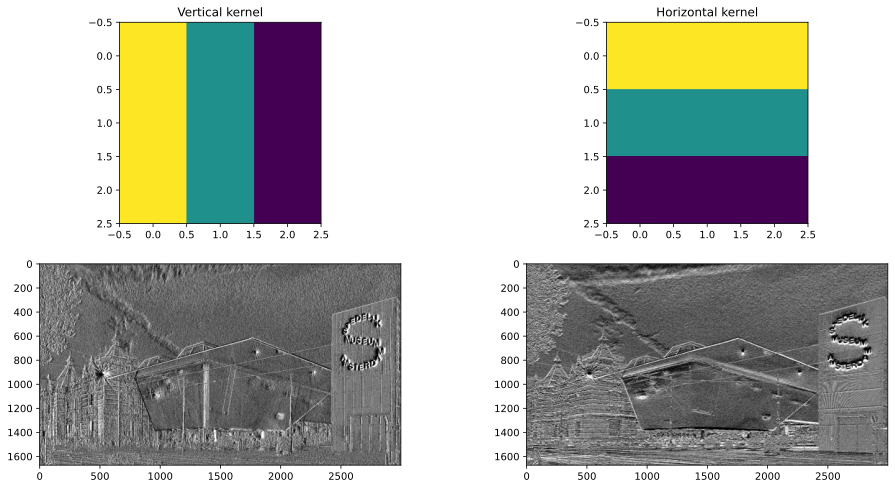

In [ ]:
fig,ax = plt.subplots(2,2,figsize=(16,8))

ax[0,0].imshow(VK)
ax[0,0].set_title('Vertical kernel')

ax[0,1].imshow(HK)
ax[0,1].set_title('Horizontal kernel')


# run convolution and show the result
convres_v = F.conv2d(bathtub_t,VK_t)
img = torch.squeeze(convres_v.detach())
ax[1,0].imshow(img,cmap='gray',vmin=0,vmax=.01)

convres_h = F.conv2d(bathtub_t,HK_t)
img = torch.squeeze(convres_h.detach())
ax[1,1].imshow(img,cmap='gray',vmin=0,vmax=.01)

plt.show()

In [ ]:
print(convres_v.shape)
print(convres_h.shape)

torch.Size([1, 1, 1673, 2998])
torch.Size([1, 1, 1673, 2998])


### trying a different size kernel

In [ ]:
def get_col(n):
    col = torch.zeros(n)
    col[: n // 2] = 1
    col[-(n // 2) :] = -1
    return col
n = 5
VK_t = torch.outer(torch.ones(n), get_col(n)).view(1,1,n,n).double()
HK_t = torch.outer(get_col(n), torch.ones(n)).view(1,1,n,n).double()

In [ ]:
bathtub_t.shape

torch.Size([1, 1, 1675, 3000])

In [ ]:
C = F.conv2d(bathtub_t,VK_t)
print(C.shape)

torch.Size([1, 1, 1671, 2996])


note that resulting dim = orig - (kernal_n - 1)

### trying convolutions on numbers from MNIST dataset

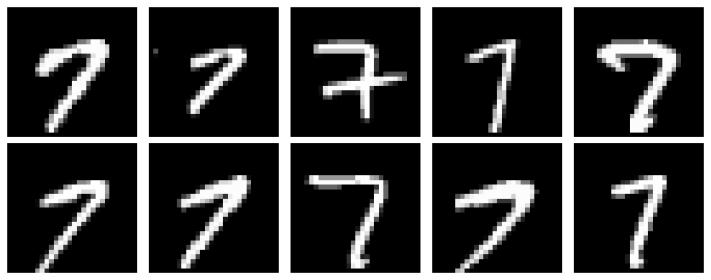

In [ ]:
import matplotlib.pyplot as plt
import subprocess
from pathlib import Path
from torchvision import datasets, transforms

# Load MNIST
project_root = Path(subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip())
download_dir = project_root / "downloads"
mnist = datasets.MNIST(
    root=download_dir,
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

# Collect first 10 sevens
seven_images = []

for image, label in mnist:
    if label == 7:
        seven_images.append(image)

    if len(seven_images) == 10:
        break

# Plot
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, img in zip(axes.flat, seven_images):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

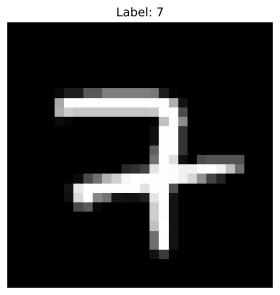

In [ ]:
import matplotlib.pyplot as plt
image = seven_images[2]
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

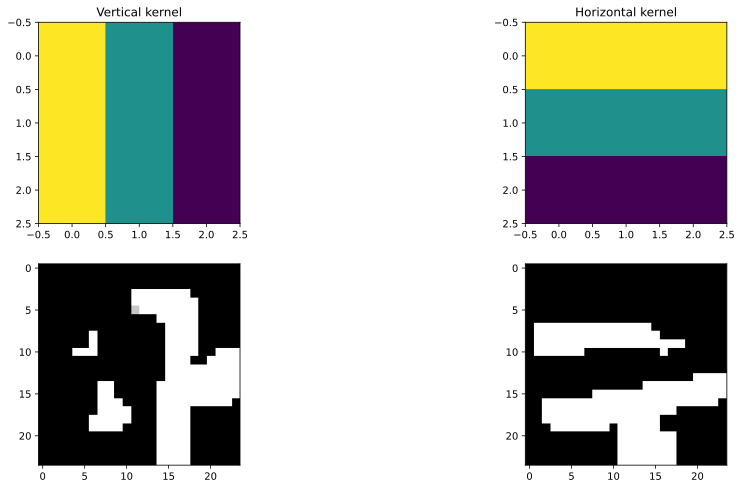

In [ ]:
# image is already a tensor from MNIST ToTensor()
image_t = image.unsqueeze(0).double()

n = 5
VK_t = torch.outer(torch.ones(n), get_col(n)).view(1,1,n,n).double()
HK_t = torch.outer(get_col(n), torch.ones(n)).view(1,1,n,n).double()
fig,ax = plt.subplots(2,2,figsize=(16,8))

ax[0,0].imshow(VK)
ax[0,0].set_title('Vertical kernel')

ax[0,1].imshow(HK)
ax[0,1].set_title('Horizontal kernel')


# run convolution and show the result
convres_v = F.conv2d(image_t,VK_t)
img = torch.squeeze(convres_v.detach())
ax[1,0].imshow(img,cmap='gray',vmin=0,vmax=.01)

convres_h = F.conv2d(image_t,HK_t)
img = torch.squeeze(convres_h.detach())
ax[1,1].imshow(img,cmap='gray',vmin=0,vmax=.01)

plt.show()